# Dimensionality Reduction — Ten Methods on the Digits Data

PCA is one way to squeeze many dimensions into a few, and it is a *linear* one: it can only rotate
and project. Real data often lies on a curved surface inside its feature space, where a linear
projection necessarily overlaps things that were separate. **Manifold learning** methods try to
unroll that surface instead.

This notebook puts ten reducers — six linear, four manifold — on the same 64-dimensional digits
data, squeezes each to 2-D, and then asks the question the pictures cannot answer on their own:
**did the reduction preserve enough to still classify?**

## Learning objectives

- Distinguish linear decomposition methods from manifold-learning methods
- Reduce the same dataset to 2-D with ten different algorithms and compare the scatter plots
- Judge an embedding by downstream classification accuracy rather than by how good it looks
- Explain why several manifold methods cannot transform new, unseen points

## Background

This notebook assumes PCA from `U1-2_Preprocess` and standardization, plus a random-forest
classifier and `classification_report` used as a downstream test. Each reducer is treated as a black
box mapping $\mathbb{R}^{64} \to \mathbb{R}^{2}$; the individual algorithms are not derived.

**Prerequisites:** `U1-2_Preprocess` (standardization, PCA), `U1-4_FeatSelect-3_PCA`

**Dataset:** `sklearn.datasets.load_digits` — 1,797 handwritten digits as 8×8 grayscale images,
flattened to 64 features.

**References:** https://scikit-learn.org/stable/modules/manifold.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load the data

Each digit is an 8×8 image flattened into a 64-element row, with pixel intensities from 0 to 16.
Sixty-four dimensions is small by image standards and still far too many to look at, which is what
makes this a good test case.

In [2]:
from sklearn.datasets import load_iris, load_digits

data = load_digits()

X = data.data
y = data.target

X[:2,:]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
         9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
        15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
         0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
        16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

A few examples rendered back into 8×8 images. They are inverted (`15 - X`) so the strokes read dark
on light.

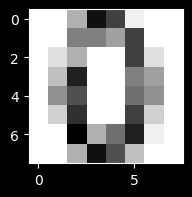

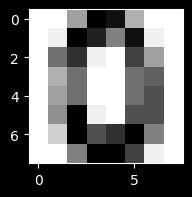

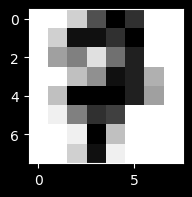

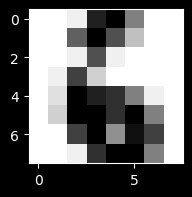

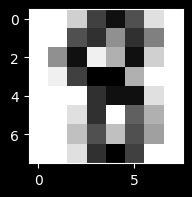

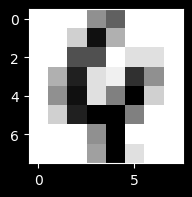

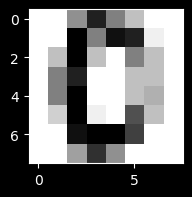

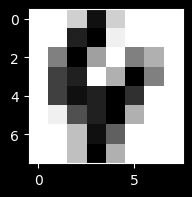

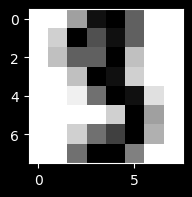

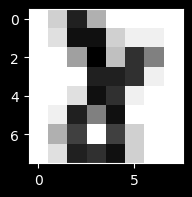

In [3]:
for i in np.random.choice( range(X.shape[0]), size=10 ).astype(int):
    x = 15 - X[i,:].reshape(8,8)
    plt.figure(figsize=(2,2))
    plt.imshow(x, cmap='gray')
    plt.show()

## 2. Standardize

Every reducer here is variance-driven or distance-driven, so feature scale decides the outcome — the
same argument as `U1-1_Embeddings-1_Tabular`. Standardizing first puts every pixel on equal footing.

Note that this is `fit_transform` on the whole array, before any split. For the exploratory 2-D
pictures in section 3 that is fine; section 4 returns to the consequences.

**One preliminary that is not cosmetic.** Three of the 64 pixels are zero in every single image —
border pixels no digit ever touches. A constant feature carries no information by definition, and
worse, it makes the data matrix rank-deficient: `FastICA` whitens its input with an SVD, and a
constant column sends that decomposition to `NaN`. We drop them first. This is a good habit
generally — a zero-variance column is never useful and is a common source of obscure failures.


In [4]:
from sklearn.preprocessing import StandardScaler

# Three of the 64 pixels are 0 in *every* image -- unused border pixels that were never
# inked. They carry no information at all, and a constant column makes the whitening
# step inside FastICA singular, so drop them before scaling.
keep = X.std(axis=0) > 0
print(f'dropping {(~keep).sum()} constant pixels -> {keep.sum()} features remain')
X = X[:, keep]

scaler = StandardScaler()
X = scaler.fit_transform(X)


dropping 3 constant pixels -> 61 features remain


## 3. Compare the reduction methods

Ten algorithms, each asked for two components. They fall into two families:

**Linear decompositions** — each new axis is a fixed weighted sum of the original 64 pixels:

- `PCA` — directions of greatest variance.
- `IncrementalPCA` — the same solution computed in batches, for data too large to hold at once.
- `TruncatedSVD` — the same idea without centering first; the standard choice for sparse data.
- `FactorAnalysis` — models the data as latent factors plus per-feature noise.
- `FastICA` — seeks *statistically independent* components rather than uncorrelated ones, which is
  a stronger requirement than PCA's.
- `KernelPCA(kernel='rbf')` — PCA performed in an implicit high-dimensional space, so the result is
  nonlinear in the original coordinates.

**Manifold learning** — no global formula, just an arrangement of *these* points that preserves some
notion of local structure:

- `Isomap` — preserves geodesic distances measured along a neighbourhood graph.
- `MDS` — preserves pairwise distances as directly as it can.
- `SpectralEmbedding` — uses the eigenvectors of a neighbourhood graph Laplacian.
- `TSNE` — preserves *neighbourhoods* rather than distances, which is why its clusters look so
  clean.

A warning about reading these plots: in a t-SNE picture the **sizes of clusters and the distances
between them are not meaningful** — the method optimizes only who is near whom. A gorgeous t-SNE
scatter is not evidence of a good representation, which is exactly why section 4 exists.

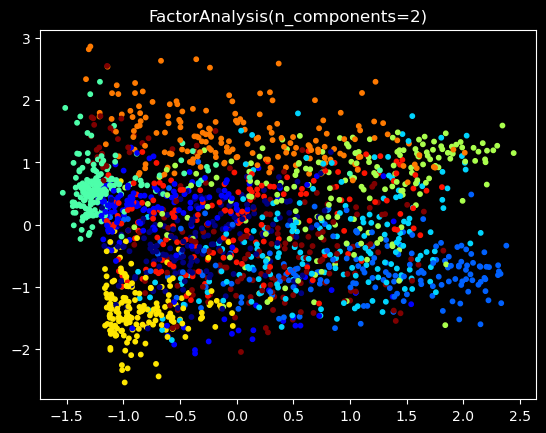

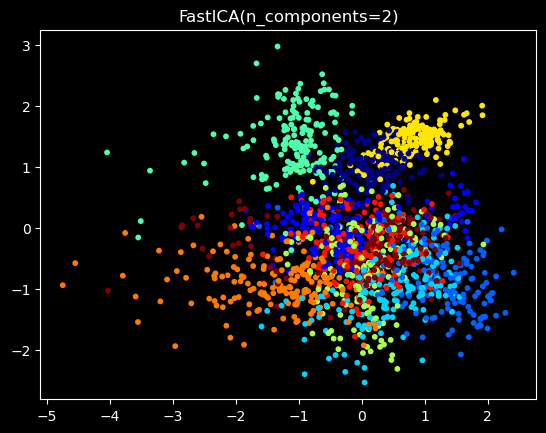

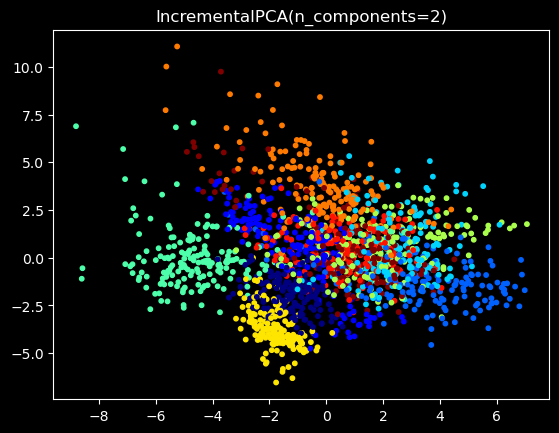

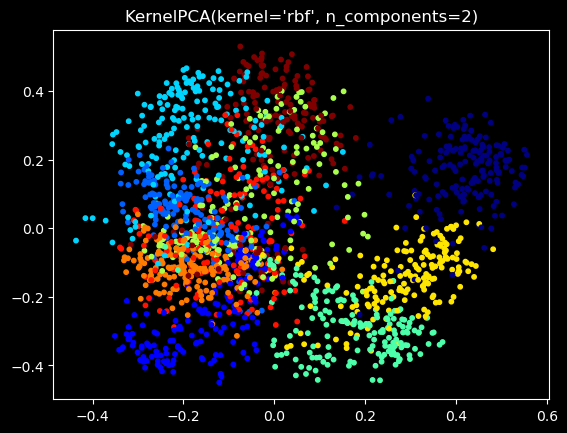

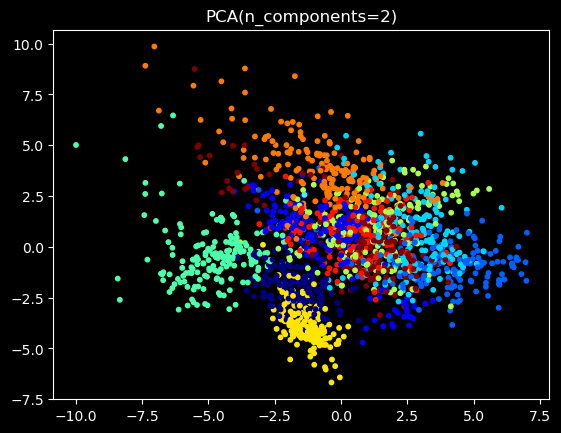

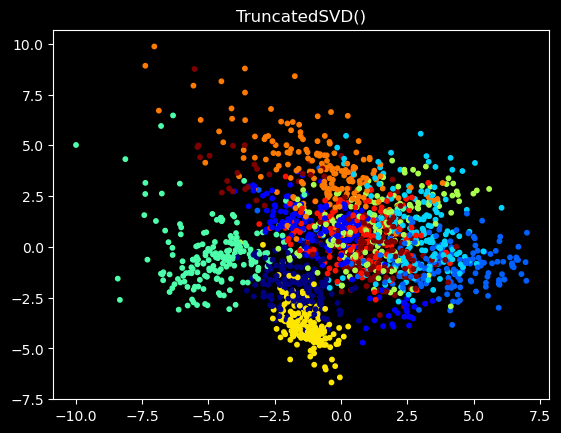

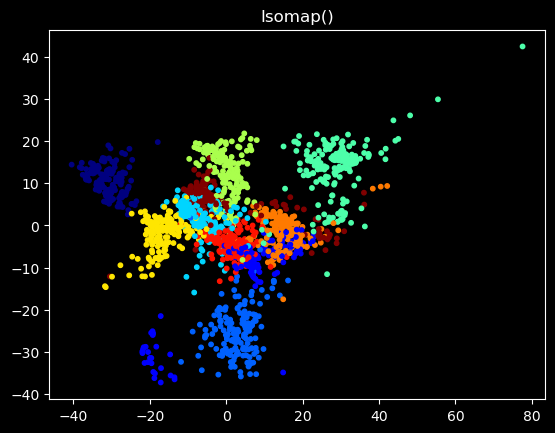

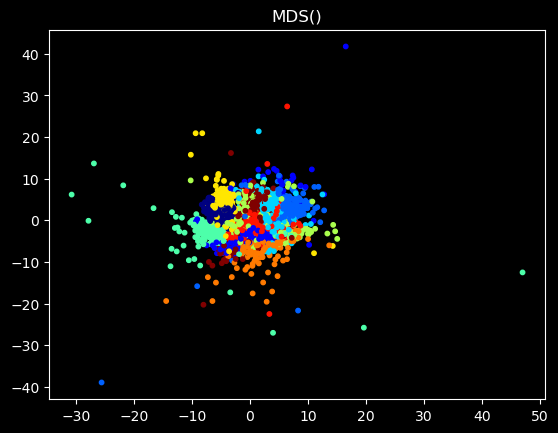

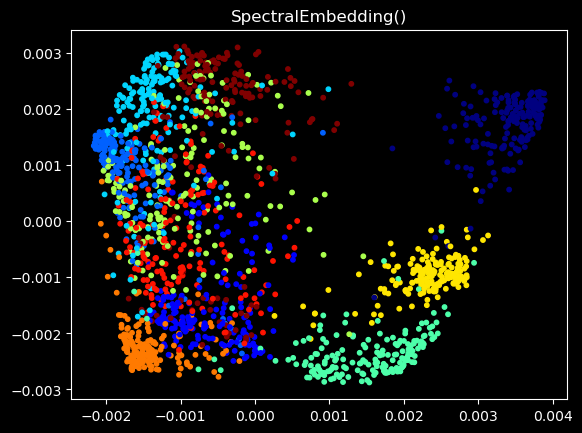

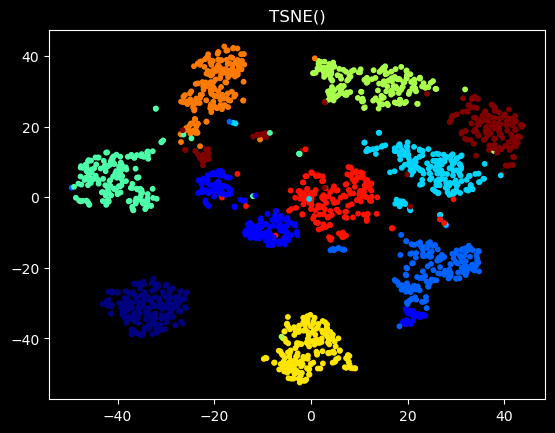

In [5]:
from sklearn.decomposition import (
    FactorAnalysis,
    FastICA,
    IncrementalPCA,
    KernelPCA,
    PCA,
    TruncatedSVD
)
from sklearn.manifold import (
    Isomap,
    MDS,
    SpectralEmbedding,
    TSNE
)

decomps = [
    # decomposition
    FactorAnalysis(n_components=2),
    FastICA(n_components=2),
    IncrementalPCA(n_components=2),
    KernelPCA(n_components=2, kernel='rbf'),
    PCA(n_components=2),
    TruncatedSVD(n_components=2),
    # manifold
    Isomap(n_components=2),
    MDS(n_components=2),
    SpectralEmbedding(n_components=2),
    TSNE(n_components=2)
]

n_decomp = len(decomps)

Xs = [ X ]
for i, model in enumerate(decomps):
    Xs.append( model.fit_transform(X) )
    
    plt.scatter(Xs[i+1][:,0],Xs[i+1][:,1], c=y, s=10, cmap='jet')
    plt.title( str(model) )
    plt.show()
# end

## 4. Does the embedding preserve what matters?

The honest test. Fit the same random-forest classifier on each 2-D embedding and on the original
64-dimensional data, and compare the classification reports.

This reframes the question from "which picture looks best?" to "which reduction kept the information
needed to tell digits apart?" — and the two answers need not agree. Compare every embedding against
the `no dimensional reduction` baseline printed first: going from 64 dimensions to 2 is a drastic
compression, and the gap to that baseline is the price paid.

**One caveat, stated plainly.** Each reducer was fit on the *entire* dataset in section 3, before
the train/test split below, so the test points influenced the embedding. Strictly this leaks, and
the accuracies here are optimistic. It is done this way because several of these methods —
`TSNE`, `MDS`, `SpectralEmbedding` — have **no `transform` method at all**: they produce an
arrangement of the points they were given and cannot place a new point without refitting. That
limitation is itself the practical lesson. If a reducer must be applied to future data, it needs a
`transform`, which restricts you to the linear family and `Isomap`.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Split the dataset into training and testing sets
idx_train, idx_test = train_test_split(range(X.shape[0]),
                                       test_size=0.2,
                                       stratify=y)

y_train = y[idx_train]
y_test = y[idx_test]

model = RandomForestClassifier(n_estimators=100)

for i in range(len(Xs)):
    X_train = Xs[i][idx_train]
    X_test  = Xs[i][idx_test]
    
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    
    if i==0:
        print('no dimensional reduction')
    else:
        print(decomps[i-1])
    # end
    
    print(classification_report(y_test, y_test_pred))
# end

no dimensional reduction
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      1.00      0.95        37
           2       1.00      1.00      1.00        35
           3       0.97      0.92      0.94        37
           4       0.97      0.92      0.94        36
           5       0.95      0.97      0.96        36
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



FactorAnalysis(n_components=2)
              precision    recall  f1-score   support

           0       0.39      0.36      0.38        36
           1       0.39      0.38      0.38        37
           2       0.47      0.46      0.46        35
           3       0.16      0.14      0.14        37
           4       0.63      0.75      0.68        36
           5       0.39      0.36      0.38        36
           6       0.60      0.75      0.67        36
           7       0.64      0.69      0.67        36
           8       0.18      0.17      0.17        35
           9       0.19      0.17      0.18        36

    accuracy                           0.42       360
   macro avg       0.40      0.42      0.41       360
weighted avg       0.40      0.42      0.41       360



FastICA(n_components=2)
              precision    recall  f1-score   support

           0       0.67      0.78      0.72        36
           1       0.40      0.62      0.49        37
           2       0.64      0.66      0.65        35
           3       0.38      0.32      0.35        37
           4       0.97      0.81      0.88        36
           5       0.34      0.33      0.34        36
           6       0.86      0.83      0.85        36
           7       0.64      0.58      0.61        36
           8       0.31      0.26      0.28        35
           9       0.32      0.28      0.30        36

    accuracy                           0.55       360
   macro avg       0.55      0.55      0.55       360
weighted avg       0.55      0.55      0.55       360



IncrementalPCA(n_components=2)
              precision    recall  f1-score   support

           0       0.60      0.72      0.66        36
           1       0.47      0.51      0.49        37
           2       0.62      0.57      0.60        35
           3       0.36      0.38      0.37        37
           4       0.76      0.81      0.78        36
           5       0.27      0.25      0.26        36
           6       0.84      0.86      0.85        36
           7       0.65      0.72      0.68        36
           8       0.15      0.11      0.13        35
           9       0.23      0.19      0.21        36

    accuracy                           0.51       360
   macro avg       0.50      0.51      0.50       360
weighted avg       0.50      0.51      0.50       360



KernelPCA(kernel='rbf', n_components=2)
              precision    recall  f1-score   support

           0       0.97      0.86      0.91        36
           1       0.56      0.86      0.68        37
           2       0.62      0.60      0.61        35
           3       0.67      0.54      0.60        37
           4       0.71      0.75      0.73        36
           5       0.24      0.22      0.23        36
           6       0.79      0.75      0.77        36
           7       0.63      0.67      0.65        36
           8       0.19      0.11      0.14        35
           9       0.50      0.58      0.54        36

    accuracy                           0.60       360
   macro avg       0.59      0.60      0.59       360
weighted avg       0.59      0.60      0.59       360



PCA(n_components=2)
              precision    recall  f1-score   support

           0       0.70      0.78      0.74        36
           1       0.43      0.57      0.49        37
           2       0.59      0.54      0.57        35
           3       0.38      0.38      0.38        37
           4       0.91      0.81      0.85        36
           5       0.35      0.36      0.36        36
           6       0.81      0.81      0.81        36
           7       0.68      0.69      0.68        36
           8       0.24      0.20      0.22        35
           9       0.32      0.28      0.30        36

    accuracy                           0.54       360
   macro avg       0.54      0.54      0.54       360
weighted avg       0.54      0.54      0.54       360



TruncatedSVD()
              precision    recall  f1-score   support

           0       0.68      0.78      0.73        36
           1       0.46      0.65      0.54        37
           2       0.58      0.54      0.56        35
           3       0.42      0.41      0.41        37
           4       0.91      0.81      0.85        36
           5       0.31      0.28      0.29        36
           6       0.81      0.81      0.81        36
           7       0.69      0.67      0.68        36
           8       0.23      0.20      0.22        35
           9       0.30      0.28      0.29        36

    accuracy                           0.54       360
   macro avg       0.54      0.54      0.54       360
weighted avg       0.54      0.54      0.54       360



Isomap()
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.62      0.68      0.65        37
           2       0.92      1.00      0.96        35
           3       0.71      0.65      0.68        37
           4       0.89      0.92      0.90        36
           5       0.86      0.86      0.86        36
           6       0.85      0.78      0.81        36
           7       0.73      0.75      0.74        36
           8       0.73      0.63      0.68        35
           9       0.76      0.81      0.78        36

    accuracy                           0.81       360
   macro avg       0.81      0.81      0.80       360
weighted avg       0.80      0.81      0.80       360



MDS()
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        36
           1       0.50      0.51      0.51        37
           2       0.73      0.69      0.71        35
           3       0.49      0.49      0.49        37
           4       0.94      0.89      0.91        36
           5       0.38      0.22      0.28        36
           6       0.69      0.67      0.68        36
           7       0.64      0.81      0.72        36
           8       0.55      0.63      0.59        35
           9       0.45      0.56      0.50        36

    accuracy                           0.62       360
   macro avg       0.62      0.62      0.61       360
weighted avg       0.62      0.62      0.61       360



SpectralEmbedding()
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.44      0.62      0.52        37
           2       0.69      0.63      0.66        35
           3       0.69      0.54      0.61        37
           4       0.86      0.89      0.88        36
           5       0.36      0.25      0.30        36
           6       0.94      0.94      0.94        36
           7       0.77      0.75      0.76        36
           8       0.38      0.40      0.39        35
           9       0.61      0.69      0.65        36

    accuracy                           0.67       360
   macro avg       0.67      0.67      0.67       360
weighted avg       0.67      0.67      0.67       360

TSNE()
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      1.00      0.95        37
           2       1.00      0.97      0.99        

## 5. Review

- **Linear methods project; manifold methods unroll.** A linear reducer defines each new axis as a
  fixed combination of the originals; a manifold method only arranges the points it was given.
- **A good-looking scatter is not a good embedding.** t-SNE's cluster sizes and separations carry no
  meaning, so judge by downstream performance instead.
- **Downstream classification is the honest test**, and the baseline is the unreduced data.
- **Several manifold methods have no `transform`.** `TSNE`, `MDS`, and `SpectralEmbedding` cannot
  place new points, which rules them out of a production pipeline and forces the leaky fit-on-all
  arrangement used here.
- **Scale first.** Every method here is driven by variance or distance, so standardization decides
  the result.